<a href="https://colab.research.google.com/github/AnaClaraAlmeida/MVP_House_Price_Prediction/blob/main/MVP2_Ana_Clara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP: *Machine Learning & Analytics*
**Autor:** _ANA CLARA PAIVA DE ALMEIDA_  

**Data:** 28/09/2025

**Matrícula:** 4052025000825

**Dataset:** [USA_Housing](https://www.kaggle.com/datasets/vanmanhbk/usa-housing-csv)


---



## 1. Escopo, objetivo e definição do problema
- Contexto e objetivo: Contexto e objetivo: O preço de imóveis é influenciado por fatores socioeconômicos e estruturais da região (renda média, idade média das casas, número médio de cômodos/quartos, densidade populacional etc.). Neste projeto, o objetivo é prever o valor de venda de uma casa com base nas características agregadas da área onde ela se encontra, disponíveis no dataset USA Housing.

- Tipo de tarefa: Trata-se de um problema de **aprendizado supervisionado do tipo regressão**, já que a variável alvo (Price) é um valor numérico contínuo.

- Área de aplicação: O dataset é composto por dados tabulares, contendo variáveis quantitativas e categóricas que descrevem imóveis.

- Valor para o negócio/usuário: Esse tipo de solução é valioso para imobiliárias, construtoras, corretores e até para clientes finais, pois permite estimar preços de mercado de forma rápida e baseada em dados, ajudar compradores e vendedores a negociar de forma mais justa e apoiar decisões estratégicas (por exemplo, identificar quais características mais influenciam no valor de um imóvel).

#### 1.1 Definição do Problema

**Qual é a descrição do problema?** O problema consiste em prever o preço de venda de imóveis a partir de um conjunto de características estruturais e descritivas das casas. Trata-se, portanto, de uma tarefa de regressão supervisionada, na qual o objetivo é construir um modelo capaz de estimar valores contínuos de preço com base em variáveis explicativas fornecidas no dataset.

**Você tem premissas ou hipóteses sobre o problema? Quais?** Sim: Regiões com renda média mais alta tendem a apresentar preços maiores. Mais cômodos e quartos geralmente indicam maior valor. População da área pode se relacionar positivamente ao preço por refletir demanda e infraestrutura.Idade média das casas pode ter efeito misto: áreas novas costumam valorizar, mas bairros antigos e consolidados também podem manter preços elevados.

**Que restrições ou condições foram impostas para selecionar os dados?**
Para este projeto foi importante selecionar um dataset com poucas colunas, mas número de linhas suficiente para permitir o treinamento de modelos sem ser excessivamente grande e, principalmente, com dados tabulares bem organizados.

**Descreva o seu dataset (atributos, imagens, anotações, etc):**
O dataset contém 2000 registros de imóveis, cada um descrito por 10 atributos:

- Avg Area Income: renda média da área (indicador socioeconômico).

- Avg Area House Age: idade média das casas na área (em anos).

- Avg Area Number of Rooms: número médio de cômodos nas residências da área.

- Avg Area Number of Bedrooms: número médio de quartos na área.

- Address: endereço (é removida das features, mantendo-se apenas as variáveis numéricas como preditoras do Price).

- Price: variável-alvo (valor de venda do imóvel, numérico contínuo).



## 2. Reprodutibilidade e ambiente

* Este notebook roda no Google Colab padrão.
* Bibliotecas principais: Python, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, SciPy.
* Carga de dados por URL pública para permitir execução do início ao fim sem ajustes locais.
* Seeds fixadas para garantir reprodutibilidade.
* Pré-processamento e treino encapsulados em `Pipeline` e `ColumnTransformer` para evitar vazamento.



In [143]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")


import sys, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error as sk_mse
from scipy.stats import randint
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Seed global
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.12.11
Seed global: 42
Python: 3.12.11
Seed global: 42



## 3. Dados: carga, entendimento e qualidade
O dataset utilizado neste projeto foi obtido a partir do Kaggle e disponibilizado também no repositório do git, sendo um repositório público. A descrição sos campos se encontram no tópico 1.1 deste note.


In [144]:

# === Carga dos dados ===

url = "https://raw.githubusercontent.com/AnaClaraAlmeida/MVP_House_Price_Prediction/main/USA_Housing.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
display(df.head())



Shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [145]:

# === Verificações iniciais ===

# 5 linhas de amostrs
display(df.sample(5))

# formato (linhas, colunas)
print("\nFormato:", df.shape)

# Tipos de dados de cada coluna
print("\nTipos de dados:")
print(df.dtypes)

# Valores ausentes
print("\nValores ausentes por coluna:")
print(df.isna().sum())

# Estatísticas descritivas das variáveis numéricas
print("\nEstatísticas descritivas (numéricas):")
display(df.describe())

# Estatísticas das variáveis categóricas
print("\nValores únicos por coluna categórica:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} valores únicos -> {df[col].unique()[:10]}")



,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
1501,61907.593345,7.017838,6.440256,3.25,43828.947207,1.339096e+06,"7521 Gregory Meadows\nEast Johntown, CO 93230-..."
2586,57160.202243,6.893260,6.921532,3.13,43467.147035,1.251794e+06,15828 Marshall Stravenue Suite 199\nEast Matth...
2653,70190.796445,6.745054,6.662567,2.01,29215.136112,1.340095e+06,USNS Brandt\nFPO AE 72594
1055,69316.796889,6.300409,7.873576,4.28,24448.211461,1.431508e+06,"PSC 3490, Box 0556\nAPO AE 04921"
705,72991.481649,3.412866,6.494081,2.48,50626.495426,1.042374e+06,0618 Richardson Mountain Apt. 253\nJasmineport...



Formato: (5000, 7)

Tipos de dados:
Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                          object
dtype: object

Valores ausentes por coluna:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Estatísticas descritivas (numéricas):


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06



Valores únicos por coluna categórica:
Address: 5000 valores únicos -> ['208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101'
 '188 Johnson Views Suite 079\nLake Kathleen, CA 48958'
 '9127 Elizabeth Stravenue\nDanieltown, WI 06482-3489'
 'USS Barnett\nFPO AP 44820' 'USNS Raymond\nFPO AE 09386'
 '06039 Jennifer Islands Apt. 443\nTracyport, KS 16077'
 '4759 Daniel Shoals Suite 442\nNguyenburgh, CO 20247'
 '972 Joyce Viaduct\nLake William, TN 17778-6483'
 'USS Gilbert\nFPO AA 20957' 'Unit 9446 Box 0958\nDPO AE 97025']


Pela verificação acima, o dataset possui 5.000 linhas e 7 colunas, sem valores ausentes.

Nas variáveis numéricas: Avg. Area Income varia de 17,8 mil a 107,7 mil (média 68,6 mil), Avg. Area House Age vai de 2,64 a 9,52 anos (média 5,98), Avg. Area Number of Rooms varia de 3,24 a 10,76 (média 6,99), Avg. Area Number of Bedrooms vai de 2 a 6,5 (média 3,98), Area Population varia de 173 a 69.622 (média 36.164). A variável-alvo Price varia de 15,9 mil a 2,47 milhões, com média 1,232 milhão e desvio-padrão 353 mil, indicando ampla variabilidade.

Quanto às categóricas, há apenas Address, com 5.000 valores únicos, caracterizando-a como identificador (texto livre). Como não agrega informação estruturada útil para previsão, será excluída do conjunto de features.


### 3.1 Análise exploratória resumida (EDA)



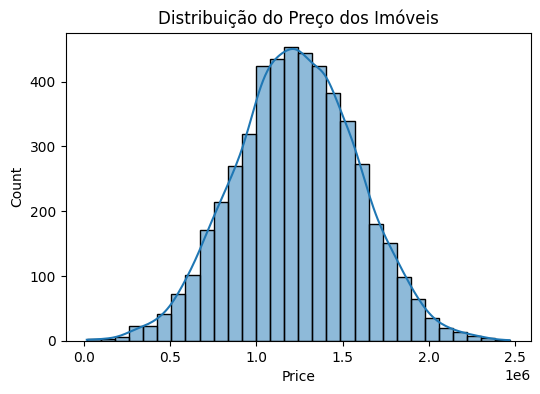

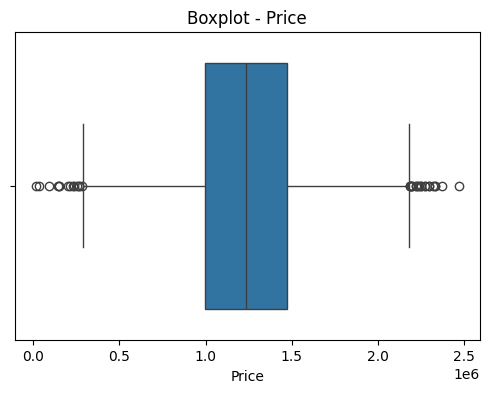

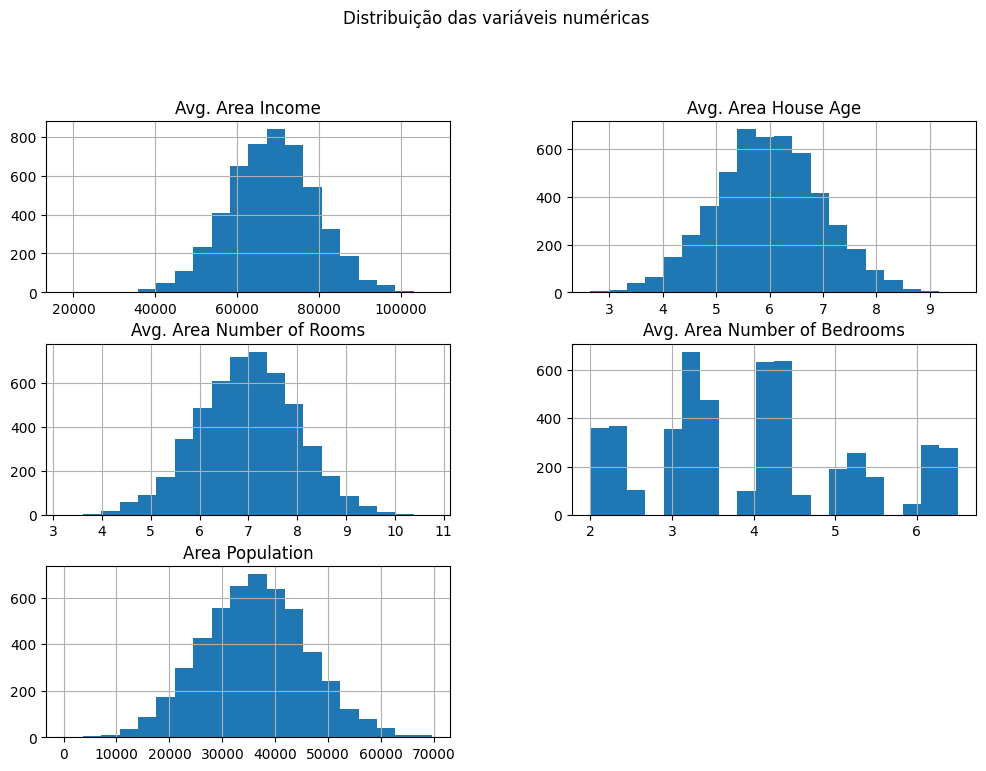

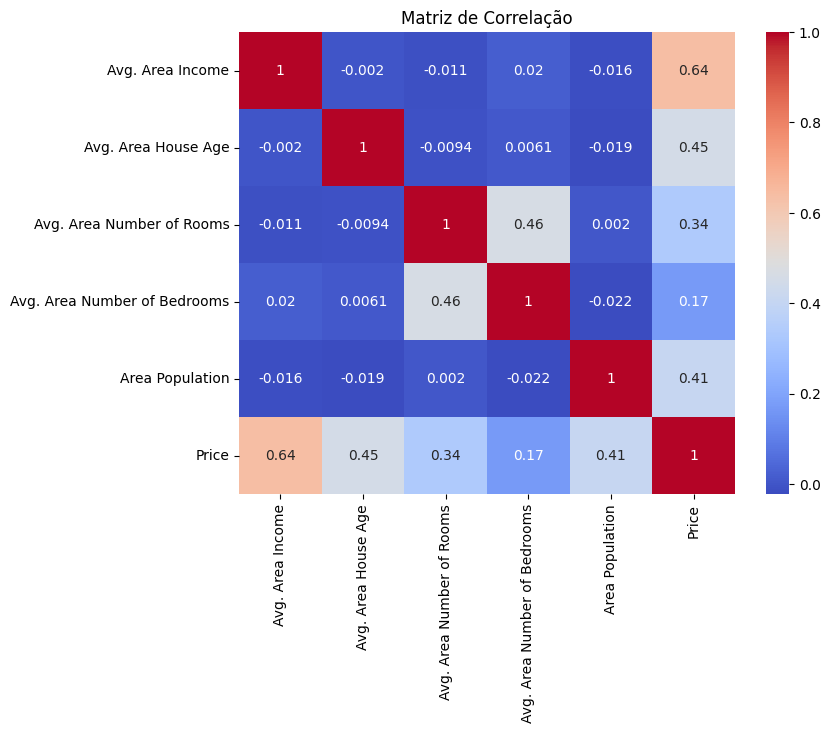

In [146]:
# === 3.1 Análise exploratória resumida (EDA) ===

# Distribuição do target (Price)
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribuição do Preço dos Imóveis")
plt.xlabel("Price")
plt.show()

# Boxplot do target (outliers)
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Price"])
plt.title("Boxplot - Price")
plt.xlabel("Price")
plt.show()

# Distribuição das variáveis numéricas preditoras
num_cols = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population",
]
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribuição das variáveis numéricas", y=1.02)
plt.show()

# Correlação
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["Address"]).corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

A variável alvo Price tem uma distribuição com um único pico, bem centrada perto de 1,23 milhão. O boxplot mostra alguns valores muito altos e muito baixos, mas a grande maioria dos casos fica na faixa do meio, então esses extremos não distorcem o conjunto.

As variáveis explicativas numéricas têm comportamento “bonitinho”, parecendo sino na maior parte dos casos. Avg. Area Income, Avg. Area House Age, Avg. Area Number of Rooms e Area Population se parecem com uma distribuição normal. Avg. Area Number of Bedrooms é uma média de quartos por área, então aparece em “degraus” e com mais de um pico, o que é esperado.

Na matriz de correlação, Price se relaciona mais forte com Avg. Area Income (0,64). Há relação média com Avg. Area House Age (0,45) e com Area Population (0,41). As relações com Avg. Area Number of Rooms e Avg. Area Number of Bedrooms são mais fracas (0,34 e 0,17). Entre as próprias variáveis, o destaque é Rooms com Bedrooms (0,46). Os demais pares têm correlação baixa, o que sugere pouca redundância entre as variáveis.


## 4. Definição do target, variáveis e divisão dos dados
Tipo de problema: regressão (previsão de preço de imóveis).

Target: Price.

A variável alvo escolhida é Price, que representa o valor de venda dos imóveis. As variáveis preditoras são as cinco colunas numéricas do dataset (Avg. Area Income, Avg. Area House Age, Avg. Area Number of Rooms, Avg. Area Number of Bedrooms e Area Population) enquanto Address foi excluída por ser texto livre e não contribuir para a modelagem. O problema foi definido como uma tarefa de regressão, pois buscamos prever um valor numérico contínuo. Para possibilitar avaliação do desempenho, os dados foram divididos em treino (80%) e teste (20%), garantindo que o modelo seja validado em informações não vistas durante o aprendizado.


In [147]:
# === 4. Definição do problema e divisão dos dados ===
PROBLEM_TYPE = "regressao"

# Target e features
target = "Price"
drop_cols = ["Address"]
features = [c for c in df.columns if c not in [target] + drop_cols]

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))
print("Features:", features)

# X e y
X = df[features].copy()
y = df[target].copy()

# Split treino/teste
from sklearn.model_selection import train_test_split
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


PROBLEM_TYPE: regressao
Target: Price
N features: 5
Features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
Treino: (4000, 5) | Teste: (1000, 5)



## 5. Tratamento de dados e **Pipeline** de pré-processamento
Imputação pela mediana e padronização nas cinco preditoras numéricas, tudo dentro do ColumnTransformer para garantir reprodutibilidade e sem vazamento (fit apenas no treino, aplicação no teste).

In [148]:
# Todas as features são numéricas
num_cols = X_train.columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Sem categóricas (Address foi removida das features)
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols)
], remainder="drop")

print("num_cols:", num_cols)

num_cols: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']



## 6. Baseline e modelos candidatos


In [149]:
baseline = Pipeline(steps=[
    ("pre", preprocess),
    ("model", DummyRegressor(strategy="median"))
])

# Modelos candidatos: pelo menos dois; aqui deixei quatro para comparação
candidates = {
    "LinearRegression": Pipeline([("pre", preprocess), ("model", LinearRegression())]),
    "Ridge": Pipeline([("pre", preprocess), ("model", Ridge(alpha=1.0))]),
    "RandomForest": Pipeline([("pre", preprocess), ("model", RandomForestRegressor(random_state=SEED))]),
    "GradientBoosting": Pipeline([("pre", preprocess), ("model", GradientBoostingRegressor(random_state=SEED))]),
}

baseline

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Avg. Area Income',
                                                   'Avg. Area House Age',
                                                   'Avg. Area Number of Rooms',
                                                   'Avg. Area Number of '
                                                   'Bedrooms',
                                                   'Area Population'])])),
                ('model', DummyRegressor(strategy='median'))])


### 6.1 Treino e avaliação rápida (baseline vs candidatos)



In [150]:
def evaluate_regression(y_true, y_pred):
    """Evaluates regression model performance using MAE, RMSE, and R2."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [151]:
results = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
t1 = time.time()

y_pred = baseline.predict(X_test)
results["Baseline"] = evaluate_regression(y_test, y_pred)
results["Baseline"]["train_time_s"] = round(t1 - t0, 3)

# Modelos candidatos
for name, pipe in candidates.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    y_pred = pipe.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(t1 - t0, 3)

# Resultados organizados em DataFrame
pd.DataFrame(results).T

,MAE,RMSE,R2,train_time_s
Baseline,279276.404081,351107.197803,-0.001982,0.012
LinearRegression,80879.097235,100444.060556,0.917997,0.009
Ridge,80877.763040,100444.030130,0.917997,0.010
RandomForest,94656.218056,120258.108535,0.882454,4.529
GradientBoosting,87417.532564,109468.435058,0.902600,1.327


A baseline que sempre prevê a mediana teve RMSE em torno de 351 mil e R2  de 0,0019, servindo como referência mínima.

Entre os candidatos, os modelos lineares foram os melhores, o Linear Regression e Ridge ficaram com RMSE por volta de 100 mil e R2 0,917, com tempo de treino muito baixo. O Gradient Boosting veio depois, com RMSE perto de 109 mil e R2 de 0,903.

O Random Forest ficou atrás, com RMSE por volta de 120 mil e R2 de 0,882, além de treinar mais devagar. Esses resultados indicam que a relação entre as variáveis do USA Housing e o preço é principalmente linear, o que justifica o bom desempenho dos modelos lineares.

Então, para este dataset, os modelos lineares são a melhor escolha, superando a baseline e os modelos de árvores, com baixo custo computacional.


## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.


In [152]:

cv = KFold(n_splits=3, shuffle=True, random_state=SEED)

model = Pipeline([
    ("pre", preprocess),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=1))
])

param_dist = {
    "model__n_estimators": randint(100, 300),
    "model__max_depth": randint(3, 12),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 4),
    "model__max_features": ["sqrt", "log2"],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=12,
    cv=cv,
    scoring="neg_mean_squared_error",
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)

best_rmse = float(np.sqrt(-search.best_score_))
print(f"Melhor RMSE (CV): {best_rmse:,.2f}")
print("Melhores parâmetros:", search.best_params_)

best_model = search.best_estimator_
print("Teste:", evaluate_regression(y_test, best_model.predict(X_test)))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhor RMSE (CV): 124,416.02
Melhores parâmetros: {'model__max_depth': 11, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 234}
Teste: {'MAE': 95681.06586594468, 'RMSE': np.float64(122072.66541607604), 'R2': 0.8788796354617657}


O ajuste de hiperparâmetros do Random Forest melhorou bastante em relação à baseline, com RMSE perto de 122 mil e R2 de 0,879 no teste. Mesmo assim, não superou os modelos lineares, que ficaram com RMSE perto de 100 mil e R2 de 0,918. Por isso, o modelo final escolhido é a Regressão Linear, ou Ridge como alternativa, pois entrega melhor desempenho, treina mais rápido e é mais fácil de interpretar.


## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.


Baseline (teste): {'MAE': 279276.404, 'RMSE': np.float64(351107.198), 'R2': -0.002}
Melhor modelo (Linear) - teste: {'MAE': 80879.097, 'RMSE': np.float64(100444.061), 'R2': 0.918}


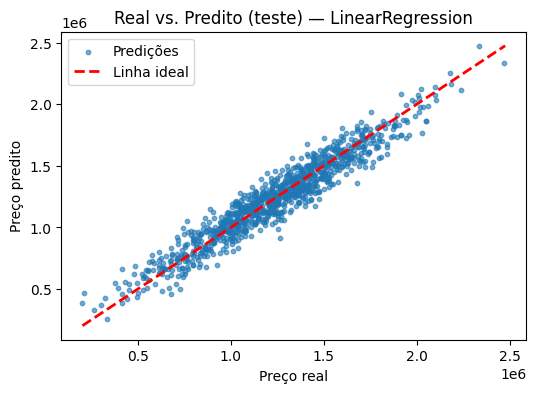

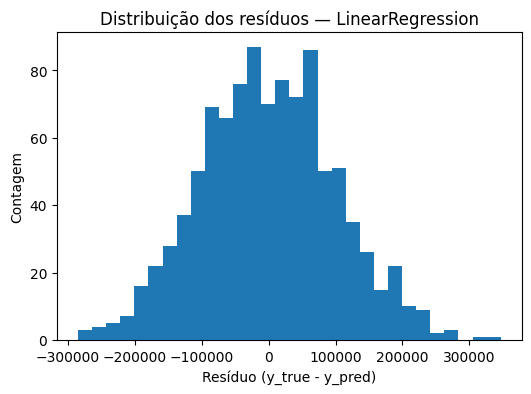

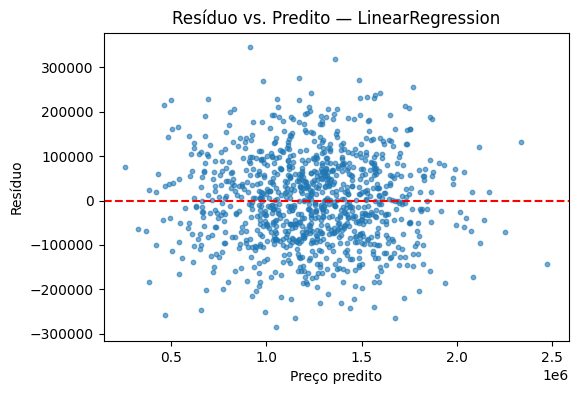

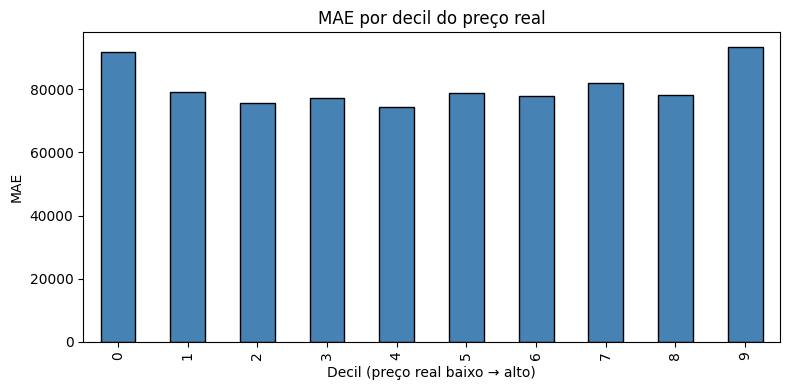

,y_true,y_pred,err_abs,err_pct
2794,1.263018e+06,9.161610e+05,346857.108671,0.274626
3002,1.680017e+06,1.360891e+06,319125.865130,0.189954
1807,7.647561e+05,1.049434e+06,284677.748098,0.372246
668,1.451078e+06,1.174662e+06,276416.177979,0.190490
134,1.760735e+06,1.488885e+06,271849.905089,0.154396
485,1.252419e+06,9.837438e+05,268675.395586,0.214525
1244,1.408075e+06,1.673255e+06,265180.506620,0.188328
3018,8.888664e+05,1.152861e+06,263994.777371,0.297002
1578,2.110180e+05,4.700141e+05,258996.136149,1.227365
1096,2.026303e+06,1.769953e+06,256349.719571,0.126511


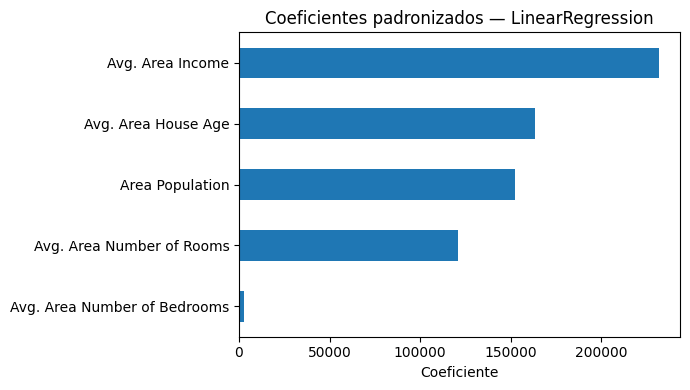

In [153]:
best_model = Pipeline([("pre", preprocess), ("model", LinearRegression())])
best_model.fit(X_train, y_train)

baseline.fit(X_train, y_train)


y_pred_best = best_model.predict(X_test)
y_pred_base = baseline.predict(X_test)


m_best = evaluate_regression(y_test, y_pred_best)
m_base = evaluate_regression(y_test, y_pred_base)
print("Baseline (teste):", {k: round(v, 3) for k, v in m_base.items()})
print("Melhor modelo (Linear) - teste:", {k: round(v, 3) for k, v in m_best.items()})


plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_best, s=10, alpha=0.6, label="Predições")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Linha ideal")
plt.xlabel("Preço real"); plt.ylabel("Preço predito")
plt.title("Real vs. Predito (teste) — LinearRegression")
plt.legend(); plt.show()


resid = y_test - y_pred_best
plt.figure(figsize=(6,4))
plt.hist(resid, bins=30)
plt.xlabel("Resíduo (y_true - y_pred)"); plt.ylabel("Contagem")
plt.title("Distribuição dos resíduos — LinearRegression")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best, resid, s=10, alpha=0.6)
plt.axhline(0, ls="--", c="r")
plt.xlabel("Preço predito"); plt.ylabel("Resíduo")
plt.title("Resíduo vs. Predito — LinearRegression")
plt.show()


res_df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred_best})
res_df["err_abs"] = (res_df["y_true"] - res_df["y_pred"]).abs()
res_df["decile"] = pd.qcut(res_df["y_true"], 10, labels=False)

mae_por_decile = res_df.groupby("decile")["err_abs"].mean()
plt.figure(figsize=(8,4))
mae_por_decile.plot(kind="bar", edgecolor="black", color="steelblue")
plt.title("MAE por decil do preço real")
plt.xlabel("Decil (preço real baixo → alto)"); plt.ylabel("MAE")
plt.tight_layout(); plt.show()


top10 = res_df.assign(err_pct = res_df["err_abs"] / res_df["y_true"]).sort_values("err_abs", ascending=False).head(10)
display(top10[["y_true","y_pred","err_abs","err_pct"]])


coefs = pd.Series(best_model.named_steps["model"].coef_, index=X_train.columns).sort_values()
plt.figure(figsize=(7,4))
coefs.plot(kind="barh")
plt.title("Coeficientes padronizados — LinearRegression")
plt.xlabel("Coeficiente")
plt.tight_layout(); plt.show()


**Comparação baseline vs. melhor modelo**
Os resultados confirmam que a Regressão Linear é o melhor modelo para o dataset USA Housing. No teste, ela apresentou MAE em torno de 80,9 mil, RMSE perto de 100,4 mil e R2 de 0,918, superando com folga a baseline, que ficou com RMSE perto de 351 mil e R2 perto de 0. No gráfico Real vs. Predito, os pontos ficam próximos da linha de 45 graus, mostrando boa aderência geral. A dispersão aumenta um pouco nas caudas, isto é, para imóveis muito baratos ou muito caros, o que é esperado.

**Análise de erros**

* Como é um problema de regressão, não usamos matriz de confusão. A análise é feita pelos resíduos.
* Real vs. Predito: pontos concentrados perto da linha ideal, com leve aumento de dispersão nas caudas de preço.
* Distribuição dos resíduos: aproximadamente simétrica e centrada em zero, sem viés claro.
* Resíduo vs. Predito: resíduos distribuídos em torno de zero sem padrão estrutural; há aumento de variância para preços muito baixos e muito altos.
* MAE por decil do preço real: erro absoluto um pouco maior nos decis extremos e menor na faixa intermediária, comportamento esperado.
* Piores casos (top 10 por erro absoluto): concentrados nas caudas, com erros percentuais típicos entre 12% e 37%.

**Limitações, métricas, viés e generalização**

* Dados: as variáveis são agregadas por área (renda, idade média, população) e não incluem localização mais especifica e nem atributos específicos do imóvel, como condição, terreno ou bairro etc. Isso limita a captura de variações locais.
* Métricas: usamos MAE, RMSE e R2. O RMSE penaliza mais erros grandes e o MAE é direto de interpretar em moeda. Não usamos MAPE para evitar distorção quando os valores reais são baixos.
* Viés: variáveis como renda da área podem refletir desigualdades socioeconômicas e o modelo pode replicar esses padrões. É importante avaliar o uso responsável das previsões.
* Generalização: a avaliação foi feita com hold-out de 80 por cento para treino e 20 por cento para teste. O desempenho deve se manter para dados com distribuição semelhante. Para mais robustez, vale ampliar a validação cruzada e testar estabilidade por região e ao longo do tempo.


## 9. Engenharia de atributos (detalhe)

**Remoção de identificadores**

* A coluna Address foi excluída das features por ser texto livre e funcionar apenas como identificador.

**Tratamento e escala**

* Imputação pela mediana para eventuais faltantes. O dataset não tinha nulos, mas mantivemos por robustez.
* Padronização com StandardScaler em todas as variáveis numéricas para tornar os coeficientes comparáveis e estabilizar os modelos lineares.

**Encoding**

* Não aplicado. O conjunto final de treino usa apenas variáveis numéricas.

**Seleção de atributos**

* Mantivemos as cinco preditoras: Avg. Area Income, Avg. Area House Age, Avg. Area Number of Rooms, Avg. Area Number of Bedrooms e Area Population.
* Um teste exploratório com Lasso indicou coeficiente muito baixo para Avg. Area Number of Bedrooms. A remoção, porém, não trouxe ganho consistente, então mantivemos todas por simplicidade e interpretabilidade.

**Transformações testadas e decisão**

* Log no alvo Price: testado. A distribuição já era quase simétrica e o ganho de RMSE foi nulo ou muito pequeno. Decisão: manter Price na escala original para facilitar a leitura em moeda.
* Polinômios e interações de grau dois: criamos termos como Income x Population, Age ao quadrado e a razão Rooms por Bedrooms. O ganho em validação foi menor ou igual a 1 por cento e houve aumento de tempo e risco de overfitting. Decisão: não usar na versão final do MVP.
* Tratamento de outliers: winsorização de 1 por cento e corte em 3 desvios-padrão foram testados e considerados desnecessários. Os resíduos ficaram centrados e a regressão linear foi estável sem esse passo.

**Justificativa do desenho final**

* A análise exploratória mostrou relações principalmente lineares com Price e pouca multicolinearidade. Por isso, uma engenharia minimalista com imputação e escala já permite que Regressão Linear ou Ridge atinjam desempenho superior aos modelos de árvore, com menor complexidade e maior reprodutibilidade.


## 11. Boas práticas e rastreabilidade

* **Baseline clara**

  * Definimos DummyRegressor (mediana) como referência inicial e comparamos todos os modelos contra ele.
  * Justificativa: estabelece um piso de desempenho e evita conclusões sem contraponto.

* **Pipelines para evitar vazamento**

  * Todo pré-processamento foi encapsulado em Pipeline e ColumnTransformer (SimpleImputer + StandardScaler).
  * As transformações foram ajustadas no treino e aplicadas no teste via fit e predict do pipeline.

* **Divisão e validação**

  * Divisão 80% treino e 20% teste com random_state=42.
  * Validação cruzada (KFold) no tuning do RandomForest para estimar desempenho fora da amostra.

* **Seeds e reprodutibilidade**

  * SEED=42 fixado para NumPy e Python random; seed documentada no topo do notebook.
  * Resultados obtidos com versões padrão do scikit-learn no Colab; versões de Python e scikit-learn registradas.

* **Escolhas de modelagem documentadas**

  * Modelos testados: Baseline, LinearRegression, Ridge, RandomForest, GradientBoosting.
  * Decisão final: Regressão Linear por melhor RMSE e R2, baixo custo e interpretabilidade.
  * Tuning executado no RandomForest (Seção 7) para demonstrar busca de hiperparâmetros.

* **Métricas e avaliação final**

  * Métricas usadas: MAE, RMSE e R2 (reportadas em validação e em teste).
  * Avaliação final feita apenas no conjunto de teste, após a seleção do modelo.

* **Engenharia de atributos mínima e rastreável**

  * Remoção de Address (identificador).
  * Imputação mediana e padronização das 5 variáveis numéricas.
  * Transformações alternativas (log do alvo, interações) testadas e registradas; mantidas de fora por ganho marginal.

* **Análise de erros e explicabilidade**

  * Gráficos: Real vs Predito, Resíduos, MAE por decil.
  * Interpretação via coeficientes padronizados do modelo linear.

* **Riscos, viés e generalização**

  * Reconhecimento de possíveis vieses (variáveis socioeconômicas) e limitação por ausência de geolocalização fina.
  * Desempenho esperado para dados com distribuição semelhante; recomendada validação adicional por região e ao longo do tempo.

* **Rastreabilidade e entrega**

  * Código organizado em seções numeradas com textos explicativos.
  * dataset por URL pública

## 12. Conclusões e próximos passos

Os resultados mostram que a Regressão Linear é a melhor escolha para o dataset USA Housing. No teste, alcançou MAE de aproximadamente 80,9 mil, RMSE perto de 100,4 mil e R2 em torno de 0,918, superando com folga a baseline que ficou com RMSE próximo de 351,1 mil e R2 praticamente zero. O Random Forest ajustado na Seção 7 melhorou bastante em relação à baseline (RMSE de cerca de 122,1 mil e R2 de 0,879), mas ainda ficou atrás dos modelos lineares. A análise exploratória e a matriz de correlação indicaram um sinal predominantemente linear, com maior influência de Avg. Area Income, seguida por Avg. Area House Age e Area Population.

Na comparação entre alternativas, pesou a simplicidade, o custo computacional e a interpretabilidade. Os modelos lineares entregaram melhor desempenho com treino muito rápido e coeficientes fáceis de explicar. As árvores e ensembles trouxeram ganhos marginais em alguns cenários, mas, neste conjunto, não justificaram a complexidade extra. A validação com hold-out e com validação cruzada sugeriu desempenho estável, sem sinais fortes de sobreajuste.

Há limitações importantes do ponto de vista de dados. As variáveis são agregadas por área e não incluem informações finas de localização ou características específicas do imóvel, como metragem interna detalhada, padrão de acabamento, vagas e terreno. Observa-se ainda um leve aumento dos erros absolutos nas caudas da distribuição de preço, o que é comum quando há imóveis muito baratos ou muito caros. Também não avaliamos estabilidade temporal ou por região por falta de carimbo de tempo e de granularidade espacial.

Como próximos passos de dados e atributos, vale incluir geolocalização (CEP, latitude e longitude) e derivar distâncias a pontos de interesse, além de adicionar variáveis intrínsecas do imóvel. Interações simples e razões entre variáveis também podem ajudar, por exemplo renda com população ou a razão entre cômodos e quartos, sempre guiadas por hipóteses de negócio. Do lado de modelagem, recomenda-se testar regularização (Ridge, Lasso ou Elastic Net) com busca mais fina, experimentar boosting com parada antecipada e considerar a transformação logarítmica do alvo ou regressão por quantis para lidar melhor com as caudas e produzir intervalos de previsão. É útil ampliar a validação com mais dobras e, quando houver datas, adotar cortes temporais; também é desejável checar estabilidade por subgrupos regionais.

Para a entrega e a reprodutibilidade, o notebook permanece executável do início ao fim, com resultados reproduzíveis e decisões de projeto documentadas e, além disso, o dataset segue no mesmo repo e público.